# 02 · LQR vs PD (Angle-Only) — Side-by-Side Comparison
Compares full-state **LQR** (all 8 states fed back) with the **angle-only PD** controller
that zeroes out the cart terms — mirroring `matlab/pid_design.m`.

Key insight: the PD controller stabilises the angles but the cart drifts, because
it has no x / ẋ feedback.

In [ ]:
# Install packages into whichever Python kernel VS Code is using
import subprocess, sys
subprocess.run([
    sys.executable, "-m", "pip", "install", "--quiet",
    "matplotlib", "numpy", "scipy", "pandas",
    "gymnasium", "stable-baselines3", "filterpy",
    "cvxpy", "clarabel",
], check=True)
print('packages ready')

In [2]:
import sys, os

# Project root (python/)
_nb_dir = os.path.abspath("")
_py_dir = _nb_dir if os.path.basename(_nb_dir) != "notebooks" else os.path.dirname(_nb_dir)
if _py_dir not in sys.path:
    sys.path.insert(0, _py_dir)

# Inject venv packages so the notebook works regardless of which kernel VS Code picks
_venv_sp = os.path.join(_py_dir, "venv", "Lib", "site-packages")
if os.path.exists(_venv_sp) and _venv_sp not in sys.path:
    sys.path.insert(0, _venv_sp)

print("Python :", sys.executable)
print("Project:", _py_dir)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
print("numpy", np.__version__, "| matplotlib", plt.matplotlib.__version__)

Python : c:\Users\aarya\OneDrive\Desktop\inverted-pendulum-control\.venv\Scripts\python.exe
Project: c:\Users\aarya\OneDrive\Desktop\inverted-pendulum-control\python
numpy 2.5.1 | matplotlib 3.11.0


## Build Controllers

In [3]:
from utils.dynamics import get_linear_system
from controllers.lqr import LQRController
from controllers.pid import PIDController
from scipy.integrate import solve_ivp
from utils.dynamics import nonlinear_dynamics

lqr = LQRController()
pd  = PIDController.from_lqr(lqr, angle_only=True, ki_x=0.0)

print("LQR gain K:", lqr.K.round(2))
print("\nPD  gain K:", pd.K_pd.round(2))

LQR gain K: [  -100.     -215.93  -2275.76  -1432.     4746.91   -937.1  -19403.22
  -3294.41]

PD  gain K: [     0.        0.    -2275.76  -1432.     4746.91   -937.1  -19403.22
  -3294.41]


## Simulate Both Controllers

In [4]:
def simulate(ctrl, x0, t_end=5.0, dt=0.02):
    t_hist, x_hist, u_hist = [0.0], [x0.copy()], []
    state = x0.copy()
    ctrl.reset()
    t = 0.0
    while t < t_end:
        u = ctrl.compute(state)
        sol = solve_ivp(lambda t_, s: nonlinear_dynamics(s, u),
                        (0, dt), state, method="RK45", max_step=dt/4)
        state = sol.y[:, -1]
        t += dt
        t_hist.append(t); x_hist.append(state.copy()); u_hist.append(u)
        # stop if fallen
        phi1, phi2, phi3 = state[2], state[2]+state[4], state[2]+state[4]+state[6]
        if max(abs(phi1),abs(phi2),abs(phi3)) > np.pi/6 or abs(state[0]) > 2.0:
            break
    return np.array(t_hist), np.array(x_hist), np.array(u_hist)

x0 = np.array([0, 0, np.deg2rad(3), 0, np.deg2rad(2), 0, np.deg2rad(1), 0])

t_lqr, X_lqr, U_lqr = simulate(lqr, x0)
t_pd,  X_pd,  U_pd  = simulate(pd,  x0)

print(f"LQR survived: {t_lqr[-1]:.2f} s  ({len(t_lqr)-1} steps)")
print(f"PD  survived: {t_pd[-1]:.2f}  s  ({len(t_pd)-1} steps)")

LQR survived: 5.02 s  (251 steps)
PD  survived: 0.72  s  (36 steps)


## Results

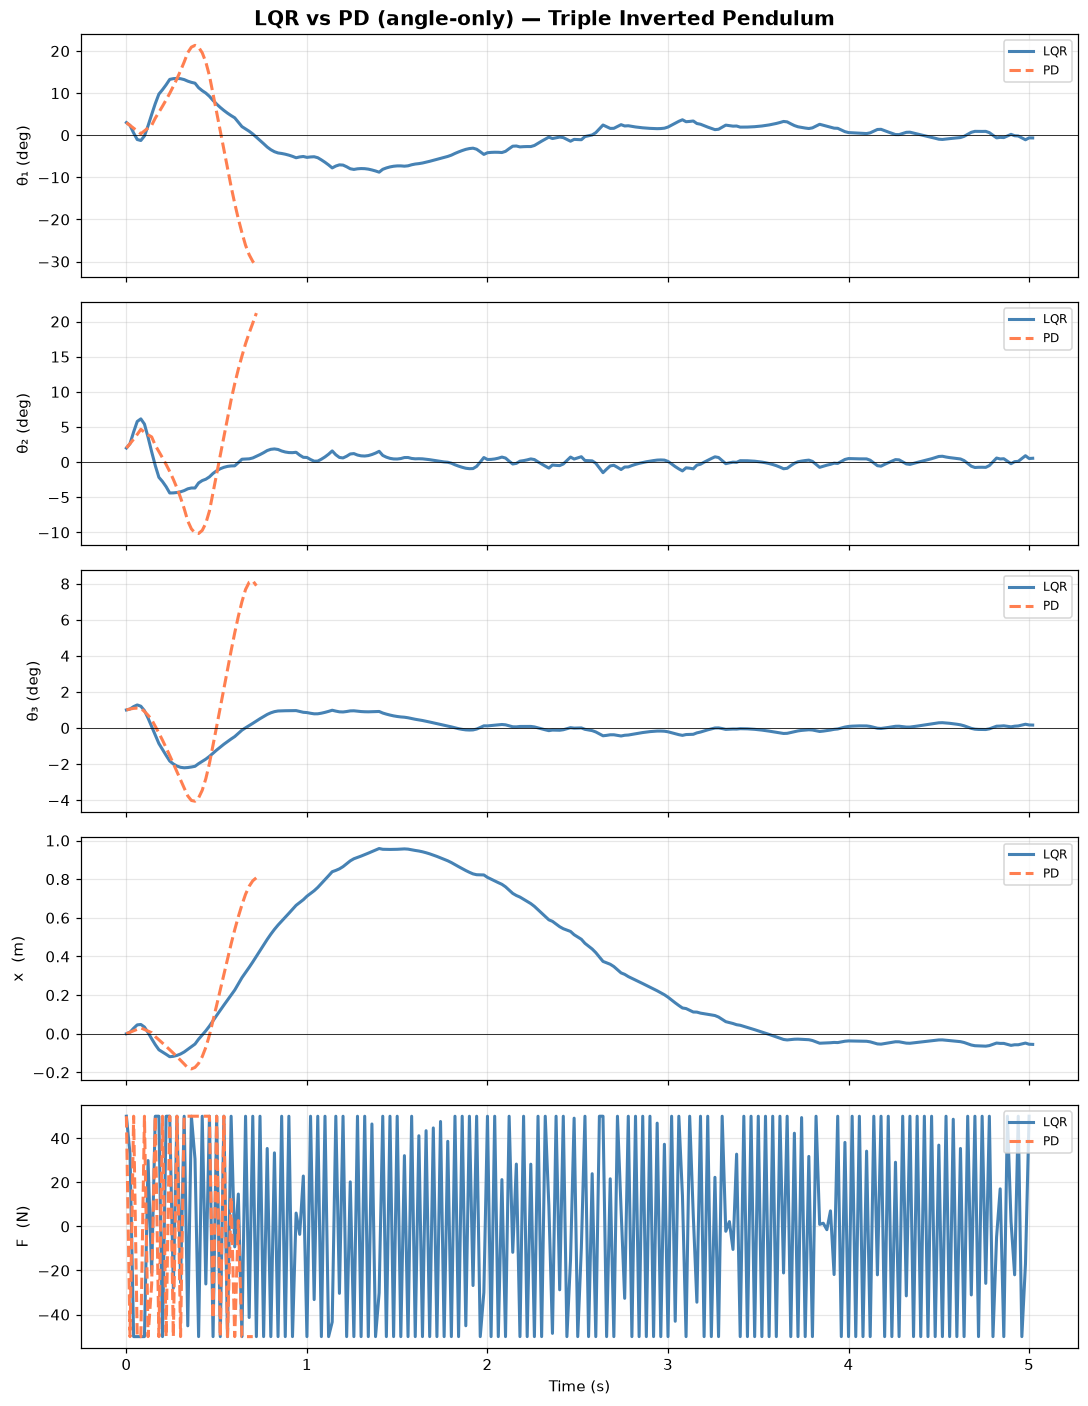

Saved → results/python/lqr_vs_pd.png


In [5]:
fig, axes = plt.subplots(5, 1, figsize=(10, 13), sharex=True)

# Absolute link angles
for i, (idx, lbl) in enumerate([(2,"θ₁"),(4,"θ₂"),(6,"θ₃")]):
    axes[i].plot(t_lqr, np.degrees(X_lqr[:, idx]), label="LQR",  color="steelblue", lw=2)
    axes[i].plot(t_pd,  np.degrees(X_pd[:,  idx]), label="PD",   color="coral",     lw=2, ls="--")
    axes[i].set_ylabel(f"{lbl} (deg)")
    axes[i].axhline(0, color="k", lw=0.5)
    axes[i].legend(loc="upper right", fontsize=8)

# Cart position
axes[3].plot(t_lqr, X_lqr[:, 0], label="LQR", color="steelblue", lw=2)
axes[3].plot(t_pd,  X_pd[:,  0], label="PD",  color="coral",     lw=2, ls="--")
axes[3].set_ylabel("x  (m)")
axes[3].axhline(0, color="k", lw=0.5)
axes[3].legend(loc="upper right", fontsize=8)

# Control force
t_u_lqr = t_lqr[:-1] if len(U_lqr) == len(t_lqr)-1 else t_lqr[:len(U_lqr)]
t_u_pd  = t_pd[:-1]  if len(U_pd)  == len(t_pd)-1  else t_pd[:len(U_pd)]
axes[4].plot(t_u_lqr, U_lqr, label="LQR", color="steelblue", lw=2)
axes[4].plot(t_u_pd,  U_pd,  label="PD",  color="coral",     lw=2, ls="--")
axes[4].set_ylabel("F  (N)"); axes[4].set_xlabel("Time (s)")
axes[4].legend(loc="upper right", fontsize=8)

fig.suptitle("LQR vs PD (angle-only) — Triple Inverted Pendulum", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../../results/python/lqr_vs_pd.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/python/lqr_vs_pd.png")

## Pendulum Animation

In [6]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from utils import parameters as p

def make_animation(t_hist, X_hist, title, dt=0.02, skip=1):
    fig, ax = plt.subplots(figsize=(8, 5))
    total_len = p.l1 + p.l2 + p.l3

    def draw(frame):
        ax.cla(); ax.set_aspect("equal")
        ax.axhline(0, color="gray", lw=1)
        state = X_hist[frame * skip]
        x = state[0]
        th1, th2, th3 = state[2], state[4], state[6]
        phi1, phi2, phi3 = th1, th1+th2, th1+th2+th3
        x1 = x + p.l1*np.sin(phi1);  y1 = p.l1*np.cos(phi1)
        x2 = x1+ p.l2*np.sin(phi2);  y2 = y1+p.l2*np.cos(phi2)
        x3 = x2+ p.l3*np.sin(phi3);  y3 = y2+p.l3*np.cos(phi3)
        ax.plot([x,x1],[0,y1],"o-",color="steelblue",lw=3,ms=6)
        ax.plot([x1,x2],[y1,y2],"o-",color="coral",lw=3,ms=6)
        ax.plot([x2,x3],[y2,y3],"o-",color="seagreen",lw=3,ms=6)
        ax.set_xlim(x-total_len-0.2, x+total_len+0.2)
        ax.set_ylim(-0.2, total_len+0.1)
        ax.set_title(f"{title}  t={frame*skip*dt:.2f}s  x={x:.2f}m")

    frames = len(X_hist) // skip
    anim = FuncAnimation(fig, draw, frames=frames, interval=dt*skip*1000)
    plt.close(fig)
    return anim

anim_lqr = make_animation(t_lqr, X_lqr, "LQR", skip=2)
HTML(anim_lqr.to_jshtml())

In [7]:
anim_pd = make_animation(t_pd, X_pd, "PD angle-only", skip=2)
HTML(anim_pd.to_jshtml())

## MPC — Constraint-Aware Planning

**Model Predictive Control (MPC)** solves a finite-horizon QP at every timestep:

$$\min \sum_{k=0}^{N-1} \bigl[x_k^\top Q x_k + R u_k^2\bigr] + x_N^\top P x_N \quad \text{s.t.} \quad x_{k+1} = A_d x_k + B_d u_k, \; |u_k| \le F_\text{max}$$

The terminal cost $P$ is the **DARE solution** (same as LQR's infinite-horizon cost-to-go), so
without constraints MPC recovers LQR exactly.  With constraints active, MPC plans the
*entire* horizon within the bounds — LQR just clips the instantaneous force and is unaware of
what comes next.

### Key demo: LQR collapses under a tight force limit; MPC does not

A triple inverted pendulum requires large initial corrective forces.  
With `F_max = 15 N` (instead of 50 N) and a 2° perturbation:

- **LQR** computes the unconstrained optimal force (~40 N), clips it to 15 N, and loses control within 0.4 s because it never anticipates the constraint.
- **MPC** looks 20 steps ahead (0.4 s of lookahead), finds the best trajectory that stays within 15 N throughout, and stabilises for the full 5 s.

In [1]:
from controllers.mpc import MPCController

# Unconstrained MPC (validates equivalence with LQR)
mpc_free = MPCController(N=20, dt=0.02, F_max=50.0, x_limit=2.0)
mpc_free.print_report()

# Force-constrained MPC — 15 N is tight enough that LQR loses control but MPC survives
F_DEMO = 15.0
mpc_constrained = MPCController(N=20, dt=0.02, F_max=F_DEMO, x_limit=2.0)

ModuleNotFoundError: No module named 'controllers'

In [ ]:
def simulate_fmax(ctrl, x0, F_max=50.0, t_end=5.0, dt=0.02):
    """Simulate with an external force clip (for LQR) or internal constraint (for MPC)."""
    t_hist, x_hist, u_hist = [0.0], [x0.copy()], []
    state = x0.copy()
    ctrl.reset()
    t = 0.0
    while t < t_end:
        u = float(np.clip(ctrl.compute(state), -F_max, F_max))
        sol = solve_ivp(lambda t_, s: nonlinear_dynamics(s, u),
                        (0, dt), state, method="RK45", max_step=dt/4)
        state = sol.y[:, -1]
        t += dt
        t_hist.append(t); x_hist.append(state.copy()); u_hist.append(u)
        phi1 = state[2]; phi2 = state[2]+state[4]; phi3 = state[2]+state[4]+state[6]
        if max(abs(phi1), abs(phi2), abs(phi3)) > np.pi/6 or abs(state[0]) > 2.0:
            break
    return np.array(t_hist), np.array(x_hist), np.array(u_hist)

# Initial condition: 2° on θ₁, proportionally less on θ₂ and θ₃
x0_demo = np.array([0, 0, np.deg2rad(2), 0, np.deg2rad(1.4), 0, np.deg2rad(0.8), 0])

# Baseline: F_max = 50 N (both should work)
t_lqr50, X_lqr50, U_lqr50 = simulate(lqr, x0_demo)
t_mpc50, X_mpc50, U_mpc50 = simulate(mpc_free, x0_demo)

# Constrained: F_max = 20 N
t_lqr20, X_lqr20, U_lqr20 = simulate_fmax(lqr, x0_demo, F_max=F_DEMO)
t_mpc20, X_mpc20, U_mpc20 = simulate_fmax(mpc_constrained, x0_demo, F_max=F_DEMO)

print(f"F_max = 50 N  →  LQR {t_lqr50[-1]:.1f} s  |  MPC {t_mpc50[-1]:.1f} s")
print(f"F_max = {F_DEMO:.0f} N  →  LQR {t_lqr20[-1]:.1f} s  |  MPC {t_mpc20[-1]:.1f} s")

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(13, 9), sharex="col")
fig.suptitle(
    f"LQR vs MPC — Force-constrained comparison  (2° initial perturbation)",
    fontsize=13, fontweight="bold",
)

def _t_u(t_hist, u_hist):
    return t_hist[:len(u_hist)], u_hist

col_cfg = [
    ("F_max = 50 N (unconstrained)", t_lqr50, X_lqr50, U_lqr50, t_mpc50, X_mpc50, U_mpc50),
    (f"F_max = {F_DEMO:.0f} N (constrained)", t_lqr20, X_lqr20, U_lqr20, t_mpc20, X_mpc20, U_mpc20),
]

for col, (title, t_l, X_l, U_l, t_m, X_m, U_m) in enumerate(col_cfg):
    # Link-1 absolute angle
    axes[0, col].plot(t_l, np.degrees(X_l[:, 2]), color="steelblue", lw=2, label="LQR")
    axes[0, col].plot(t_m, np.degrees(X_m[:, 2]), color="darkorange", lw=2, ls="--", label="MPC")
    axes[0, col].set_ylabel("θ₁  (deg)")
    axes[0, col].set_title(title)
    axes[0, col].legend(fontsize=8)

    # Cart position
    axes[1, col].plot(t_l, X_l[:, 0], color="steelblue", lw=2, label="LQR")
    axes[1, col].plot(t_m, X_m[:, 0], color="darkorange", lw=2, ls="--", label="MPC")
    axes[1, col].set_ylabel("x  (m)")

    # Control force
    tu_l, u_l = _t_u(t_l, U_l)
    tu_m, u_m = _t_u(t_m, U_m)
    axes[2, col].plot(tu_l, u_l, color="steelblue", lw=2, label="LQR")
    axes[2, col].plot(tu_m, u_m, color="darkorange", lw=2, ls="--", label="MPC")
    axes[2, col].axhline( F_DEMO if col == 1 else 50, color="k", ls=":", lw=1, label="±F_max")
    axes[2, col].axhline(-F_DEMO if col == 1 else -50, color="k", ls=":", lw=1)
    axes[2, col].set_ylabel("F  (N)"); axes[2, col].set_xlabel("Time (s)")

for ax in axes.flat:
    ax.axhline(0, color="k", lw=0.5)

plt.tight_layout()
plt.savefig("../../results/python/lqr_vs_mpc.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/python/lqr_vs_mpc.png")

In [ ]:
anim_mpc = make_animation(t_mpc20, X_mpc20, f"MPC  (F_max = {F_DEMO:.0f} N)", skip=2)
HTML(anim_mpc.to_jshtml())